In [3]:
from vq_acdc.data import load_dataset, ACDCDataset, OneHotEncode, PercentileClip, MinMaxNormalize
import os

from torchvision.transforms import Compose
from torchvision import transforms

from torch.utils.data import DataLoader

from matplotlib import pyplot as plt



/home/infres/ihamdaoui-21/VQ-ACDC/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

L = 64 # image size L=W
BATCH_SIZE = 5


In [6]:
dataset_path = "/home/ids/ihamdaoui-21/ACDC/database"

train_set_path = os.path.join(dataset_path, "training")
test_set_path  = os.path.join(dataset_path, "testing")


In [11]:
train_dataset = load_dataset(train_set_path)
test_dataset  = load_dataset(test_set_path)


input_transforms = Compose([
    transforms.Resize(size=(L,L), interpolation=transforms.InterpolationMode.NEAREST),
    OneHotEncode(num_classes=4)
    ])


TrainDataset = ACDCDataset(train_dataset, transform= input_transforms) 
# TestDataset  = ACDCDataset(data = test_dataset, transforms= input_transforms)

TrainLoader  = DataLoader(TrainDataset, batch_size = BATCH_SIZE, shuffle = True)
# TestLoader   = DataLoader(TestDataset , batch_size = BATCH_SIZE, shuffle = True)

torch.Size([103, 103])


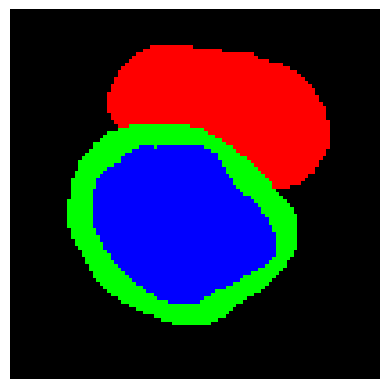

In [14]:
from matplotlib.colors import ListedColormap

custom_colors = [
    '#000000', '#ff0000', '#00ff00', '#0000ff']

cmap = ListedColormap(custom_colors)

slice = train_dataset[20]
plt.imshow(slice , cmap)
plt.axis('off')

print(slice.shape)

Batch shape: torch.Size([5, 4, 64, 64])


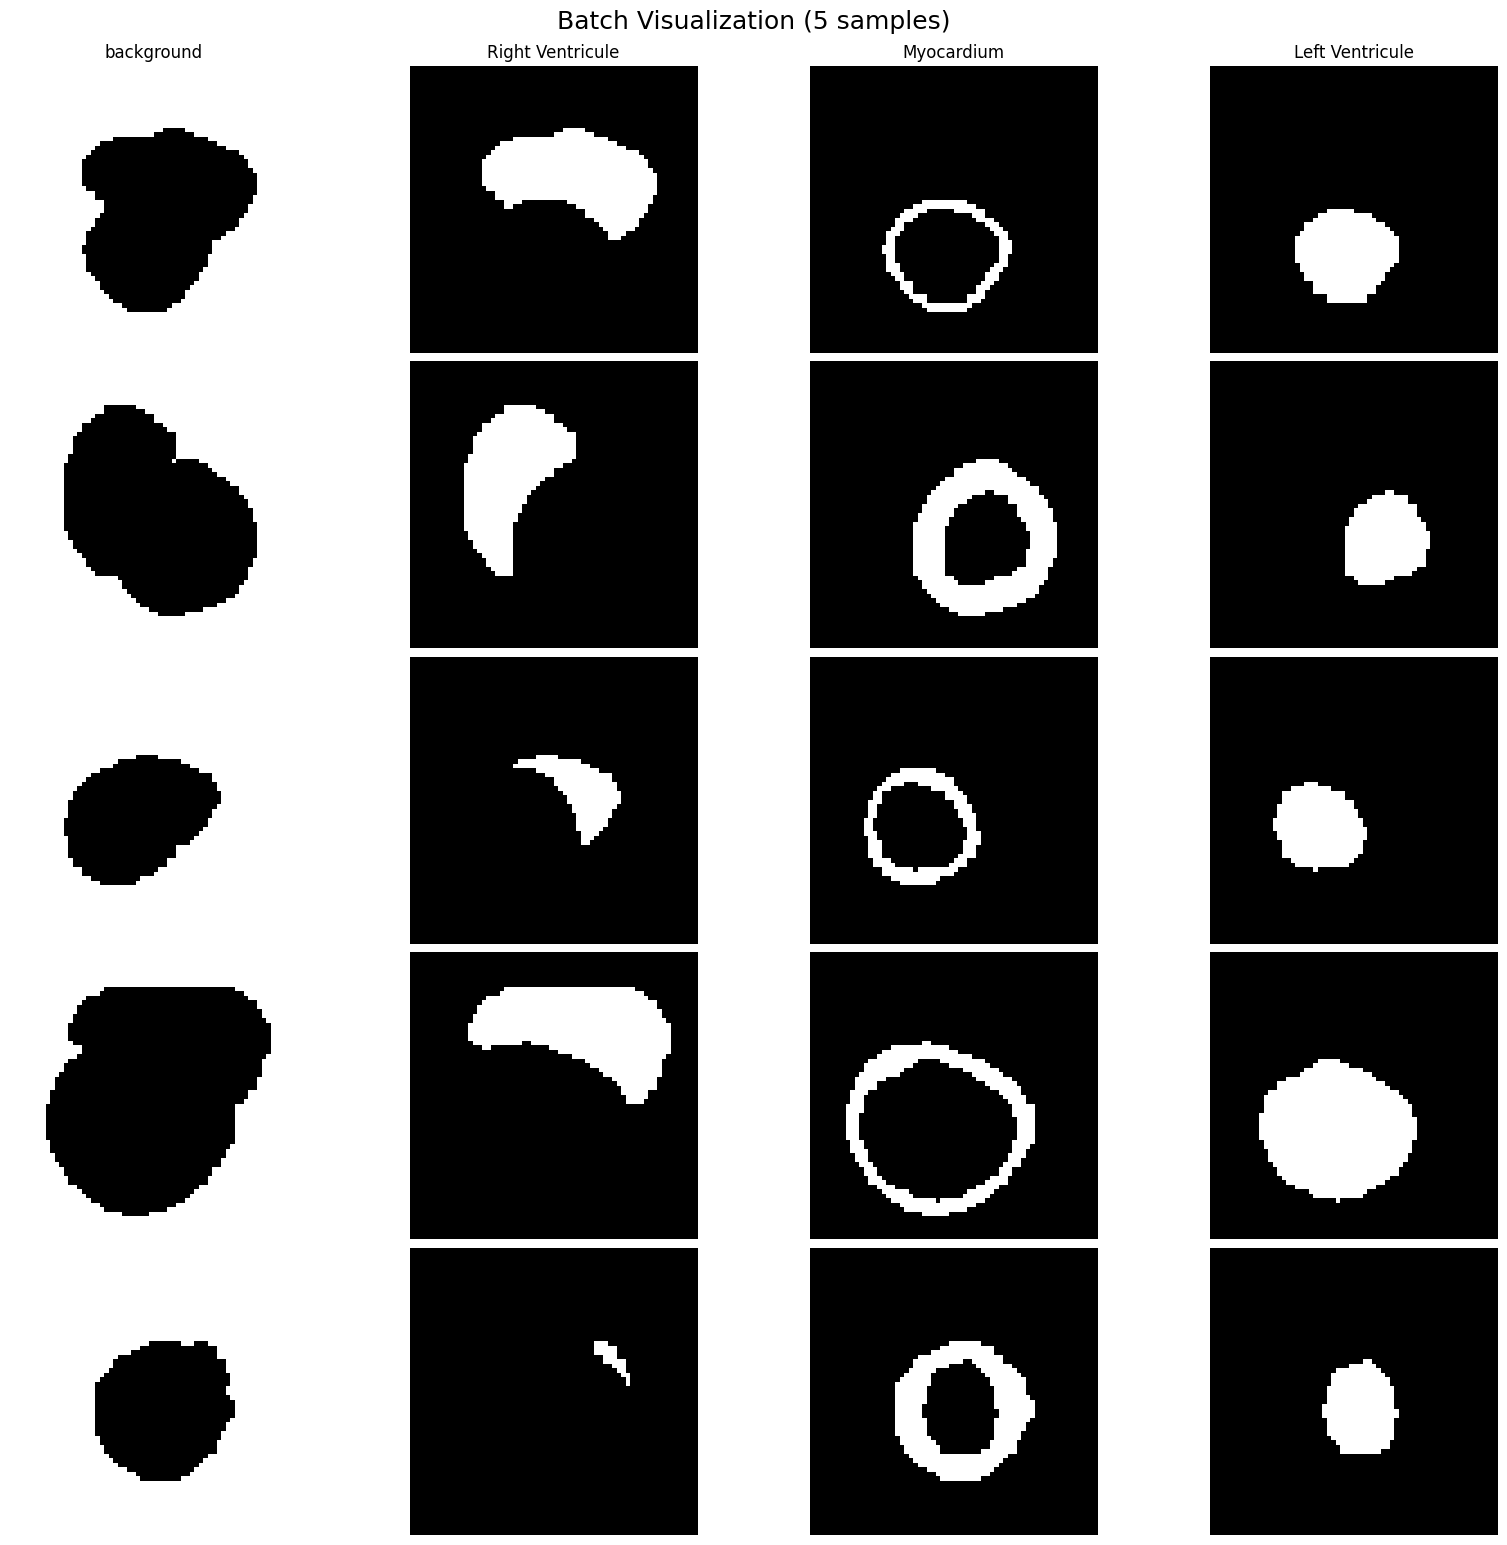

In [16]:
import matplotlib.pyplot as plt
import torch

batch = next(iter(TrainLoader))

def visualize_batch(batch, samples=8):
    """
    Visualize a batch of multi-channel images.
    Expected shape: [B, C, H, W]
    """

    batch_size, channels, H, W = batch.shape
    samples = min(samples, batch_size)

    # Move to CPU if tensor is on GPU
    if torch.is_tensor(batch):
        batch = batch.detach().cpu()

    fig, axes = plt.subplots(
        samples,
        channels,
        figsize=(4 * channels, 3 * samples),
        constrained_layout=True
    )

    # Handle edge case when samples=1
    if samples == 1:
        axes = axes[None, :]

    channel_titles = ["background", "Right Ventricule", "Myocardium", "Left Ventricule"]

    for i in range(samples):
        img = batch[i]

        for c in range(channels):
            ax = axes[i, c]

            ax.imshow(
                img[c],
                cmap="gray",
                vmin=img[c].min(),
                vmax=img[c].max()
            )

            # Titles only on first row
            if i == 0:
                ax.set_title(channel_titles[c], fontsize=12)

            # Sample label on left
            if c == 0:
                ax.set_ylabel(
                    f"Sample {i}",
                    rotation=90,
                    fontsize=11
                )

            ax.axis("off")

    fig.suptitle(
        f"Batch Visualization ({samples} samples)",
        fontsize=18,
        y=1.02
    )

    plt.show()


# Example usage
print(f"Batch shape: {batch.shape}")
visualize_batch(batch, samples=8)